# 06 — Hourly Baseline Model

本 Notebook 呈現 2023 年轉乘相關借車量的 Baseline Model 實驗。目標是預測 100 個高需求站點的目標小時借車量；它不是全體 YouBike 需求，也不是 30／60 分鐘可用車數。

In [1]:
from pathlib import Path
import matplotlib.pyplot as plt
import pandas as pd

ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
metrics = pd.read_csv(ROOT / 'results/baseline_metrics.csv')
splits = pd.read_csv(ROOT / 'results/baseline_split_summary.csv')
station_errors = pd.read_csv(ROOT / 'results/baseline_station_errors.csv')
hour_errors = pd.read_csv(ROOT / 'results/baseline_hour_errors.csv')
splits

,split,rows,stations,start,end,average_target,zero_target_percent
0,train,638098,100,2023-01-08T00:00:00+08:00,2023-09-30T23:00:00+08:00,5.243669,28.652025
1,validation,146400,100,2023-10-01T00:00:00+08:00,2023-11-30T23:00:00+08:00,4.140171,30.779372
2,test,74282,100,2023-12-01T00:00:00+08:00,2023-12-31T23:00:00+08:00,4.011012,30.999435


## 時間切分

1–9 月訓練、10–11 月驗證、12 月測試。站點排名只使用訓練期；Ridge alpha 只使用驗證集選擇，測試集不參與選模。

,model,split,alpha,rows,mae,rmse,r2
7,ridge_time_history_weather,test,0.1,74282,1.793286,2.889303,0.735536
5,ridge_time_history,test,100.0,74282,1.809618,2.911339,0.731487
3,seasonal_168h,test,NaN,74282,2.176274,3.700872,0.566102
2,persistence_1h,test,NaN,74282,2.441305,4.129208,0.459852


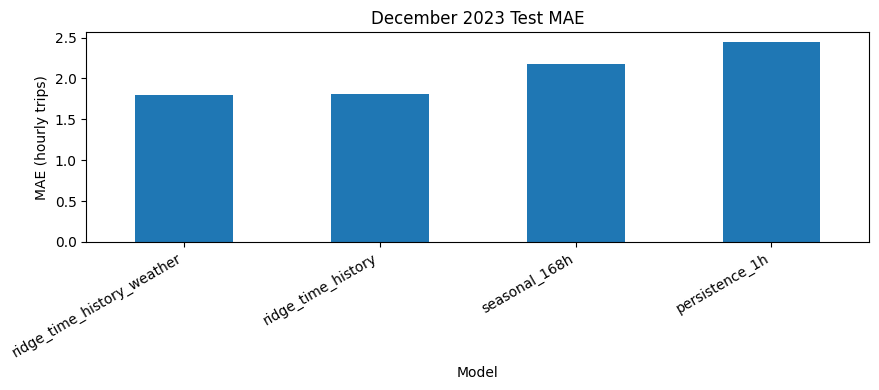

In [2]:
test_metrics = metrics.query("split == 'test'").sort_values('mae')
display(test_metrics)
ax = test_metrics.plot.bar(x='model', y='mae', figsize=(9, 4), legend=False)
ax.set(title='December 2023 Test MAE', xlabel='Model', ylabel='MAE (hourly trips)')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

## 天氣增量

天氣 Ridge 與不含天氣 Ridge 使用相同站點、切分與歷史特徵，因此兩者差異可作為本次實驗中的增量比較；但使用的是事後歷史天氣，正式部署仍應改用天氣預報。

In [3]:
indexed = test_metrics.set_index('model')
weather = indexed.loc['ridge_time_history_weather']
no_weather = indexed.loc['ridge_time_history']
seasonal = indexed.loc['seasonal_168h']
pd.Series({
    'MAE improvement vs seasonal (%)': (seasonal.mae - weather.mae) / seasonal.mae * 100,
    'MAE improvement from weather (%)': (no_weather.mae - weather.mae) / no_weather.mae * 100,
    'RMSE improvement from weather (%)': (no_weather.rmse - weather.rmse) / no_weather.rmse * 100,
})

MAE improvement vs seasonal (%)      17.598364
MAE improvement from weather (%)      0.902532
RMSE improvement from weather (%)     0.756900
dtype: float64

## 誤差分析
尖峰時段與最高需求站點的絕對誤差較大，是下一階段模型改善的重點。

/var/folders/ks/w1ns79m97v73dhf2r3q6_zm00000gn/T/ipykernel_39715/3780184104.py:7: UserWarning: Glyph 25463 (\N{CJK UNIFIED IDEOGRAPH-6377}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/ks/w1ns79m97v73dhf2r3q6_zm00000gn/T/ipykernel_39715/3780184104.py:7: UserWarning: Glyph 36939 (\N{CJK UNIFIED IDEOGRAPH-904B}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/ks/w1ns79m97v73dhf2r3q6_zm00000gn/T/ipykernel_39715/3780184104.py:7: UserWarning: Glyph 20845 (\N{CJK UNIFIED IDEOGRAPH-516D}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/ks/w1ns79m97v73dhf2r3q6_zm00000gn/T/ipykernel_39715/3780184104.py:7: UserWarning: Glyph 24373 (\N{CJK UNIFIED IDEOGRAPH-5F35}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/ks/w1ns79m97v73dhf2r3q6_zm00000gn/T/ipykernel_39715/3780184104.py:7: UserWarning: Glyph 29313 (\N{CJK UNIFIED IDEOGRAPH-7281}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/ks/w1ns79m97

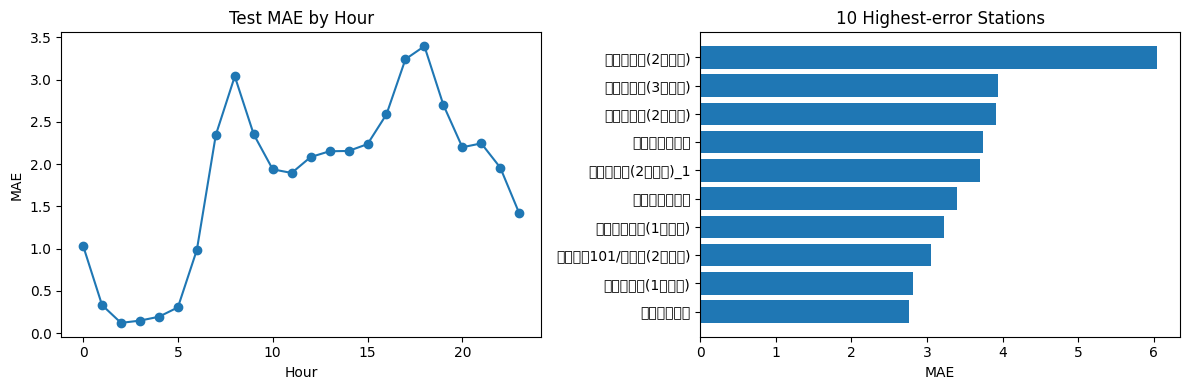

,station_name,rows,average_actual,average_prediction,mae
0,捷運公館站(2號出口),744,20.987903,20.971178,6.045141
1,捷運公館站(3號出口),744,11.005376,10.914437,3.939918
2,捷運劍潭站(2號出口),742,9.749326,10.258342,3.918887
3,捷運科技大樓站,744,11.994624,11.953242,3.747143
4,捷運芝山站(2號出口)_1,744,11.327957,11.462850,3.695778
5,捷運中山國中站,744,9.239247,9.295407,3.391556
6,捷運龍山寺站(1號出口),744,9.754032,9.699091,3.230176
7,捷運臺北101/世貿站(2號出口),737,7.436906,7.452338,3.056649
8,捷運圓山站(1號出口),743,7.664872,7.671592,2.816585
9,捷運六張犁站,743,8.029610,8.012936,2.760775


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(hour_errors['hour'], hour_errors['mae'], marker='o')
axes[0].set(title='Test MAE by Hour', xlabel='Hour', ylabel='MAE')
top_errors = station_errors.head(10).sort_values('mae')
axes[1].barh(top_errors['station_name'], top_errors['mae'])
axes[1].set(title='10 Highest-error Stations', xlabel='MAE')
plt.tight_layout()
plt.show()
station_errors.head(10)

## 結論

Ridge 明顯優於兩個 naive baselines，證明站點、週期時間與過去需求能提供有效訊號。天氣有一致但幅度有限的增益。下一步應比較樹模型並針對 07:00–09:00、17:00–19:00 與高需求站點進行誤差分析。